# MO-IT148 Homework: Line Plot of IoT Sensor Readings Over Time

This notebook visualizes different IoT sensor readings retrieved and processed from the blockchain smart tracking dataset.

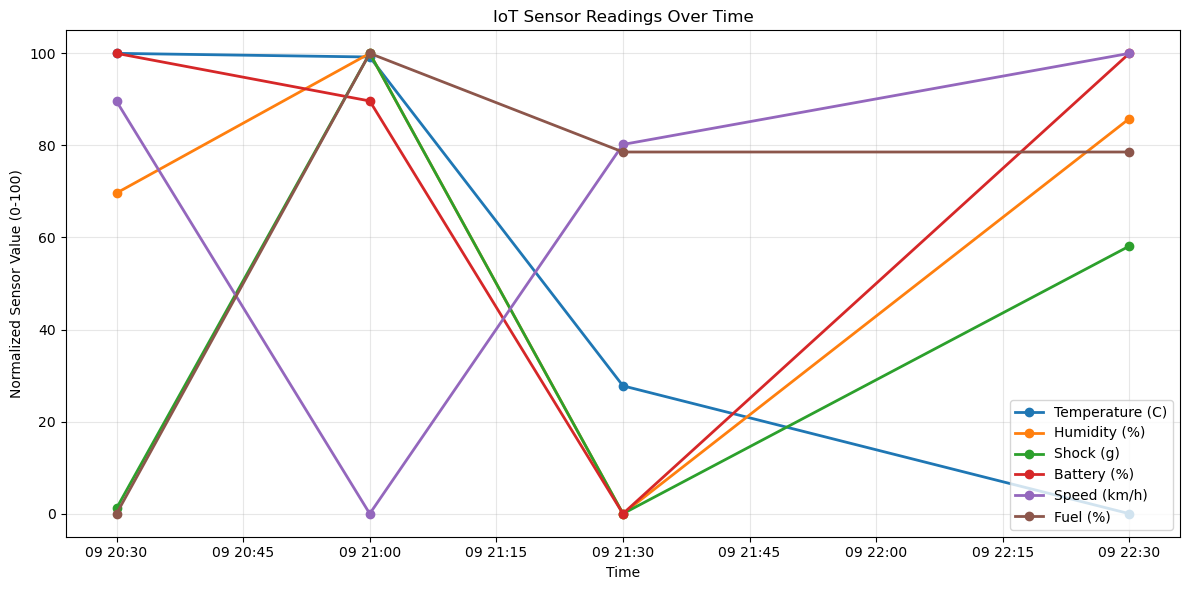

                     temperature_c  humidity_percent  shock_g_force  \
source_timestamp                                                      
2026-05-09 20:30:00          7.995            62.150         0.7450   
2026-05-09 21:00:00          7.990            63.960         0.9940   
2026-05-09 21:30:00          7.540            57.995         0.7420   
2026-05-09 22:30:00          7.365            63.115         0.8885   

                     battery_percent  speed_kmh  fuel_percent  
source_timestamp                                               
2026-05-09 20:30:00            86.25       56.5         52.25  
2026-05-09 21:00:00            85.95       13.5         62.75  
2026-05-09 21:30:00            83.35       52.0         60.50  
2026-05-09 22:30:00            86.25       61.5         60.50  


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_zip_blockchain_records.csv")
df["source_timestamp"] = pd.to_datetime(df["source_timestamp"], errors="coerce")

sensors = {
    "temperature_c": "Temperature (C)",
    "humidity_percent": "Humidity (%)",
    "shock_g_force": "Shock (g)",
    "battery_percent": "Battery (%)",
    "speed_kmh": "Speed (km/h)",
    "fuel_percent": "Fuel (%)",
}

for col in sensors:
    df[col] = pd.to_numeric(df[col], errors="coerce")

time_series = (
    df.set_index("source_timestamp")
    .resample("30min")[list(sensors.keys())]
    .mean()
    .dropna(how="all")
)

normalized = (time_series - time_series.min()) / (time_series.max() - time_series.min()) * 100

plt.figure(figsize=(12, 6))
for col, label in sensors.items():
    plt.plot(normalized.index, normalized[col], marker="o", linewidth=2, label=label)

plt.title("IoT Sensor Readings Over Time")
plt.xlabel("Time")
plt.ylabel("Normalized Sensor Value (0-100)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("week7_multisensor_line_plot.png", dpi=160)
plt.show()

print(time_series)


## Insights

The line graph compares multiple sensor types over time using normalized values. Temperature and humidity show environmental condition changes, shock highlights possible handling issues, and battery/fuel trends support device and vehicle monitoring. A sudden rise in shock or temperature would be treated as a possible anomaly.